# Are the Explanations Faithful? (mask-free)

This asks a deeper question: *do heatmaps reflect what the model actually used?* — with **no masks**, so it cannot be circular.

### Method: deletion & insertion (Petsiuk et al., RISE, 2018)
- **Deletion.** Remove the pixels the heatmap calls most important, a few at a time, and watch the predicted-class probability. If the heatmap is faithful, confidence should **drop fast**. → lower deletion-AUC is better.
- **Insertion.** Start from a blurred image and add the most-important pixels back. Faithful heatmaps make confidence **rise fast**. → higher insertion-AUC is better.

### The baseline that makes it rigorous
We run the same test with a **random** heatmap. Grad-CAM is only "faithful" if it beats random at picking pixels that matter. This is the faithfulness analogue of Notebook 4's mask-fraction baseline.

### Important 
A heatmap can miss the tumour yet still be *faithful* — accurately showing the model looked elsewhere. So faithfulness and localisation are different axes:
- low localisation + **high** faithfulness → the CAM correctly reveals the model isn't using the tumour (direct shortcut evidence).
- low localisation + **low** faithfulness → the CAM is just unreliable.

In [1]:
# Cell 1 — install + imports
!pip install grad-cam==1.5.4 timm --quiet

from pathlib import Path
import numpy as np, pandas as pd
import torch, timm
from scipy.ndimage import gaussian_filter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU — slow. Turn on the T4.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 47.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda


## Cell 2 — settings

`N_EVAL` images per model keeps this tractable (deletion/insertion is expensive). 50 is plenty for a stable mean. `STEPS` is how finely we remove/add pixels. Pilot with `SEEDS=[42]`.

In [2]:
# Cell 2
IN_DIR  = "/kaggle/input"
OUT_DIR = "/kaggle/working/faith"

ARCH   = "resnet18"
SEEDS  = [42,1,2]                 # pilot; then [42, 1, 2]
FOLDS  = [0, 1, 2, 3, 4]
N_EVAL = 50                   # images sampled per model
STEPS  = 50                   # deletion/insertion granularity
SAMPLE_SEED = 0

In [3]:
# Cell 3 — locate inputs
def find(name):
    hits = list(Path(IN_DIR).rglob(name))
    assert hits, f"{name} not found under {IN_DIR}."
    return hits[0]

images   = np.load(find("images.npy"))
manifest = pd.read_csv(find("manifest_splits.csv"))
MODEL_DIR = find(f"model_{ARCH}_seed{SEEDS[0]}_fold_honest_fold0.pt").parent
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("images", images.shape, "| models in", MODEL_DIR)

images (3064, 224, 224) | models in /kaggle/input/notebooks/souravpaul100304/3b-multiseed/runs_multiseed


## Cell 4 — the deletion/insertion engine

For one image and one heatmap: rank pixels by importance, then build the whole sequence of progressively-deleted and progressively-inserted images, run them through the model in two batches, and integrate the probability curves into AUCs. Batching the steps keeps it fast.

In [4]:
# Cell 4 — core metric
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

def prep(arr2d):
    a = np.stack([arr2d]*3, axis=-1)
    a = (a - IMAGENET_MEAN)/IMAGENET_STD
    return a.transpose(2,0,1).astype(np.float32)

def deletion_insertion(model, img_uint8, attribution, steps=50):
    H, W = img_uint8.shape
    raw = img_uint8.astype(np.float32)/255.0
    blurred = gaussian_filter(raw, sigma=8)
    order = np.argsort(attribution.flatten())[::-1]   # most important first
    n = H*W; step = max(1, n//steps)

    with torch.no_grad():
        x0 = torch.from_numpy(prep(raw)).unsqueeze(0).to(device)
        pred = int(model(x0).argmax(1).item())

    del_imgs, ins_imgs, fracs = [], [], []
    rflat, bflat = raw.flatten(), blurred.flatten()
    for s in range(steps+1):
        k = s*step
        d = rflat.copy(); d[order[:k]] = 0.0
        ins = bflat.copy(); ins[order[:k]] = rflat[order[:k]]
        del_imgs.append(prep(d.reshape(H,W)))
        ins_imgs.append(prep(ins.reshape(H,W)))
        fracs.append(k/n)

    with torch.no_grad():
        dp = torch.softmax(model(torch.from_numpy(np.stack(del_imgs)).to(device)),1)[:,pred].cpu().numpy()
        ip = torch.softmax(model(torch.from_numpy(np.stack(ins_imgs)).to(device)),1)[:,pred].cpu().numpy()

    return float(np.trapz(dp, fracs)), float(np.trapz(ip, fracs)), pred
print("engine ready")

engine ready


## Cell 5 — model + attribution

In [5]:
# Cell 5 — load model, get Grad-CAM
def load_model(seed, split_col, fold):
    m = timm.create_model(ARCH, pretrained=False, num_classes=3)
    m.load_state_dict(torch.load(MODEL_DIR/f"model_{ARCH}_seed{seed}_{split_col}_fold{fold}.pt",
                                 map_location=device))
    return m.to(device).eval()

def gradcam_map(cam_engine, model, img_uint8):
    x = torch.from_numpy(prep(img_uint8.astype(np.float32)/255.0)).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = int(model(x).argmax(1).item())
    return cam_engine(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
print("ready")

ready


## Cell 6 — run

For each model, sample `N_EVAL` images from its test fold and compute deletion/insertion AUC for **Grad-CAM** and for a **random** heatmap (the baseline).

In [6]:
# Cell 6 — run
rng = np.random.default_rng(SAMPLE_SEED)
rows = []
for seed in SEEDS:
    for split_col in ["fold_honest","fold_leaky"]:
        for fold in FOLDS:
            model = load_model(seed, split_col, fold)
            cam_engine = GradCAM(model=model, target_layers=[model.layer4[-1]])
            test_idx = np.where((manifest[split_col]==fold).values)[0]
            pick = rng.choice(test_idx, min(N_EVAL, len(test_idx)), replace=False)
            for i in pick:
                cam = gradcam_map(cam_engine, model, images[i])
                d_g, i_g, pred = deletion_insertion(model, images[i], cam, STEPS)
                rand = rng.random(cam.shape)
                d_r, i_r, _ = deletion_insertion(model, images[i], rand, STEPS)
                rows.append({"seed":seed,"split":split_col,"fold":fold,"idx":int(i),
                             "del_gradcam":d_g,"ins_gradcam":i_g,
                             "del_random":d_r,"ins_random":i_r})
            del model, cam_engine; torch.cuda.empty_cache()
        print(f"seed {seed} {split_col}: done")

df = pd.DataFrame(rows)
df.to_csv(Path(OUT_DIR)/"faithfulness.csv", index=False)
print("saved faithfulness.csv,", len(df), "rows")

/tmp/ipykernel_22/1417053231.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(dp, fracs)), float(np.trapz(ip, fracs)), pred


seed 42 fold_honest: done
seed 42 fold_leaky: done
seed 1 fold_honest: done
seed 1 fold_leaky: done
seed 2 fold_honest: done
seed 2 fold_leaky: done
saved faithfulness.csv, 1500 rows


## Cell 7 — the result

Grad-CAM vs random, honest vs leaky.

- **Deletion** (lower = better): is Grad-CAM's deletion-AUC clearly *below* random's? If yes, Grad-CAM identifies pixels that genuinely matter → faithful. If it's ~equal to random, the heatmap is not faithful.
- **Insertion** (higher = better): same logic, opposite direction.

Then compare honest vs leaky: if faithfulness is similar, explanations again fail to distinguish the sound model from the compromised one.

In [7]:
# Cell 7 — summarise
def tab(col):
    return df.groupby("split")[col].agg(["mean","std"]).round(4)

print("DELETION-AUC  (lower = more faithful)")
print("  Grad-CAM:\n", tab("del_gradcam").to_string())
print("  Random  :\n", tab("del_random").to_string())
print("\nINSERTION-AUC (higher = more faithful)")
print("  Grad-CAM:\n", tab("ins_gradcam").to_string())
print("  Random  :\n", tab("ins_random").to_string())

print("\nFAITHFULNESS GAP (Grad-CAM minus Random):")
for split in ["fold_honest","fold_leaky"]:
    s = df[df.split==split]
    dgap = s.del_gradcam.mean() - s.del_random.mean()   # want negative
    igap = s.ins_gradcam.mean() - s.ins_random.mean()   # want positive
    print(f"  {split}: deletion {dgap:+.4f} (want <0)   insertion {igap:+.4f} (want >0)")

DELETION-AUC  (lower = more faithful)
  Grad-CAM:
                mean     std
split                      
fold_honest  0.4907  0.1770
fold_leaky   0.5119  0.1612
  Random  :
                mean     std
split                      
fold_honest  0.5155  0.2733
fold_leaky   0.5350  0.2944

INSERTION-AUC (higher = more faithful)
  Grad-CAM:
                mean     std
split                      
fold_honest  0.9178  0.1012
fold_leaky   0.9305  0.0738
  Random  :
                mean     std
split                      
fold_honest  0.6452  0.3201
fold_leaky   0.6591  0.3086

FAITHFULNESS GAP (Grad-CAM minus Random):
  fold_honest: deletion -0.0248 (want <0)   insertion +0.2726 (want >0)
  fold_leaky: deletion -0.0231 (want <0)   insertion +0.2713 (want >0)


## Cell 8 — Quantus corroboration (optional)

Runs the recognised Quantus toolkit's Faithfulness Correlation on a small sample.

In [8]:
# Cell 8 — optional Quantus check
try:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","quantus","--quiet"], check=True)
    import quantus
    seed, split_col, fold = SEEDS[0], "fold_honest", 0
    model = load_model(seed, split_col, fold)
    cam_engine = GradCAM(model=model, target_layers=[model.layer4[-1]])
    test_idx = np.where((manifest[split_col]==fold).values)[0][:24]

    xb = np.stack([prep(images[i].astype(np.float32)/255.0) for i in test_idx])
    yb = (manifest["label"].values-1)[test_idx].astype(int)
    ab = np.stack([gradcam_map(cam_engine, model, images[i])[None,...] for i in test_idx])

    metric = quantus.FaithfulnessCorrelation(nr_runs=30, subset_size=224,
                perturb_baseline="black", abs=False, normalise=True,
                return_aggregate=False, disable_warnings=True)
    sc = metric(model=model, x_batch=xb, y_batch=yb, a_batch=ab,
                device=device, channel_first=True)
    print(f"Quantus FaithfulnessCorrelation (honest fold0): mean {np.nanmean(sc):.4f}")
    print("Positive = attributions track prediction changes. Near 0 = not faithful.")
except Exception as e:
    print("Quantus check skipped:", type(e).__name__, str(e)[:200])
    print("Rely on the deletion/insertion result above.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.8/281.8 kB 10.2 MB/s eta 0:00:00
Quantus FaithfulnessCorrelation (honest fold0): mean 0.0581
Positive = attributions track prediction changes. Near 0 = not faithful.


## Cell 9 — example curves

Deletion and insertion curves for a few images: Grad-CAM vs random. A faithful Grad-CAM deletion curve drops below the random one; the insertion curve rises above it.

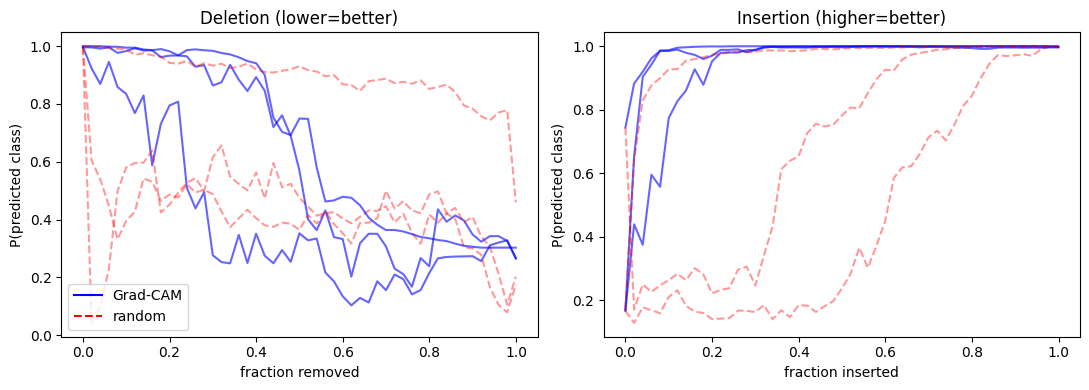

In [9]:
# Cell 9 — curves
import matplotlib.pyplot as plt
seed, split_col, fold = SEEDS[0], "fold_honest", 0
model = load_model(seed, split_col, fold)
cam_engine = GradCAM(model=model, target_layers=[model.layer4[-1]])
test_idx = np.where((manifest[split_col]==fold).values)[0]
pick = np.random.default_rng(1).choice(test_idx, 3, replace=False)

def curves(img_uint8, attribution, steps=50):
    H,W = img_uint8.shape; raw = img_uint8.astype(np.float32)/255.0
    blurred = gaussian_filter(raw, sigma=8)
    order = np.argsort(attribution.flatten())[::-1]; n=H*W; step=max(1,n//steps)
    with torch.no_grad():
        pred = int(model(torch.from_numpy(prep(raw)).unsqueeze(0).to(device)).argmax(1).item())
    di, ii, fr = [], [], []
    for s in range(steps+1):
        k=s*step
        d=raw.flatten().copy(); d[order[:k]]=0.0
        ins=blurred.flatten().copy(); ins[order[:k]]=raw.flatten()[order[:k]]
        di.append(prep(d.reshape(H,W))); ii.append(prep(ins.reshape(H,W))); fr.append(k/n)
    with torch.no_grad():
        dp=torch.softmax(model(torch.from_numpy(np.stack(di)).to(device)),1)[:,pred].cpu().numpy()
        ip=torch.softmax(model(torch.from_numpy(np.stack(ii)).to(device)),1)[:,pred].cpu().numpy()
    return fr, dp, ip

fig, axes = plt.subplots(1, 2, figsize=(11,4))
for i in pick:
    cam = gradcam_map(cam_engine, model, images[i])
    rnd = np.random.default_rng(2).random(cam.shape)
    fr, dg, ig = curves(images[i], cam)
    _,  dr, ir = curves(images[i], rnd)
    axes[0].plot(fr, dg, "b", alpha=.6); axes[0].plot(fr, dr, "r--", alpha=.4)
    axes[1].plot(fr, ig, "b", alpha=.6); axes[1].plot(fr, ir, "r--", alpha=.4)
axes[0].set_title("Deletion (lower=better)"); axes[0].set_xlabel("fraction removed")
axes[1].set_title("Insertion (higher=better)"); axes[1].set_xlabel("fraction inserted")
axes[0].plot([],[], "b", label="Grad-CAM"); axes[0].plot([],[], "r--", label="random"); axes[0].legend()
for a in axes: a.set_ylabel("P(predicted class)")
plt.tight_layout(); plt.savefig(Path(OUT_DIR)/"faithfulness_curves.png", dpi=130); plt.show()